# Prediccion de unidades vendidas e importe de venta total

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [14]:
df = pd.read_csv("PruebaChida1000Datos.csv")
print(df.head(5))

  Unidades Vendidas Importe de Venta Total
0                xi                     yi
1              5530          843,767.40 € 
2               994          419,358.66 € 
3              6845        1,408,016.50 € 
4              9806           91,489.98 € 


In [2]:
df["Unidades Vendidas"] = pd.to_numeric(df["Unidades Vendidas"])
df["Importe de Venta Total"] = pd.to_numeric(df["Importe de Venta Total"])
%matplotlib inline
plt.plot(df["Unidades Vendidas"], df["Importe de Venta Total"], "b.")
plt.xlabel("Unidades Vendidas")
plt.ylabel("Importe de Venta Total")
plt.show()

NameError: name 'pd' is not defined

# Construir un modelo

In [38]:
Prediccion = LinearRegression()
Prediccion.fit(df["Altura"].values.reshape(-1, 1), df["Peso"].values)
print("Pendiente (m):", Prediccion.coef_[0])
print("Intercepto (b):", Prediccion.intercept_)

Pendiente (m): 3.432676129271628
Intercepto (b): -106.02770644878126


In [47]:
df["Altura"] = pd.to_numeric(df["Altura"], errors="coerce")
df["Peso"] = pd.to_numeric(df["Peso"], errors="coerce")
df = df.dropna()
Prediccion = LinearRegression()
Prediccion.fit(df["Altura"].values.reshape(-1, 1), df["Peso"].values)
X_min_max = np.array([[df["Altura"].min()], [df["Altura"].max()]])
y_train_pred = Prediccion.predict(X_min_max)
print("Predicción en altura mínima:", y_train_pred[0])
print("Predicción en altura máxima:", y_train_pred[1])


Predicción en altura mínima: 111.70694043091811
Predicción en altura máxima: 147.64705950439208


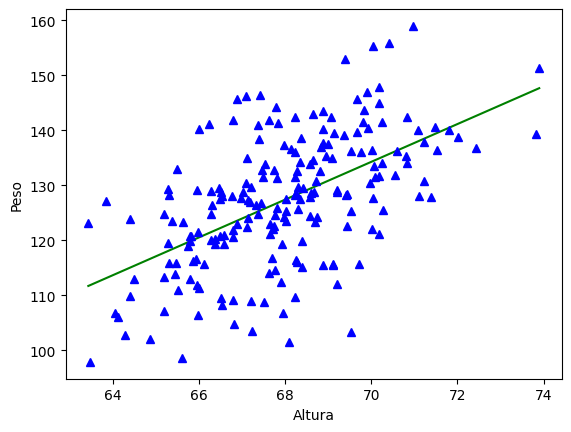

In [51]:
# Representacion grafica de la funcion de hipotesis
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(df["Altura"], df["Peso"], "b^")
plt.xlabel("Altura")
plt.ylabel("Peso")
plt.show()

## Prediccion

In [70]:
X_new = np.array([[69]])
Altura = Prediccion.predict(X_new)
print("La altura del coreanito seria de:", int(Altura[0]), "cm")

La altura del coreanito seria de: 130 cm


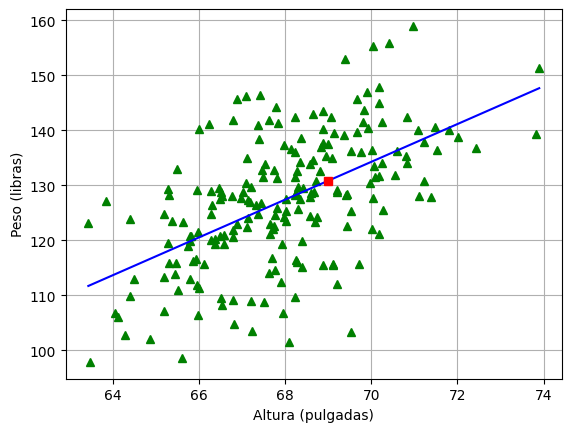

In [ ]:
plt.plot(df["Altura"], df["Peso"], "g^")
plt.plot(X_min_max, y_train_pred, "b-")
plt.plot(X_new, Altura, "rs")
plt.xlabel("Altura (pulgadas)")
plt.ylabel("Peso (libras)")
plt.grid(True)
plt.show()